In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import os
os.chdir(os.path.dirname(os.getcwd()))
print(os.getcwd())
load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("✓ Conectado a nodus_denue")

C:\Users\axela\Documents\nodus-denue-analysis
✓ Conectado a nodus_denue


In [2]:
df_check = pd.read_sql("""
    SELECT DISTINCT nombre_act 
    FROM denue_clean 
    ORDER BY nombre_act 
    LIMIT 50
""", engine)

df_check[df_check['nombre_act'].str.contains('[^\x20-\x7E]', na=False)]

,nombre_act
2,Actividades Agrícolas Combinadas Con Aprovecha...
3,Actividades Agrícolas Combinadas Con Explotaci...
4,Actividades Agrícolas Combinadas Con Explotaci...
6,Acuã±Aciã³n E Impresiã³n De Monedas
7,Acuñación E Impresión De Monedas
8,Administraciã³n De Aeropuertos Y Helipuertos
9,Administraciã³n De Cajas De Pensiã³n Y De Segu...
10,Administraciã³n De Cementerios Pertenecientes ...
11,Administraciã³n De Cementerios Pertenecientes ...
12,Administraciã³n De Puertos Y Muelles


In [3]:
df_resumen = pd.read_sql("""
    SELECT
        COUNT(*)                    AS total_empresas,
        SUM(CASE WHEN geo_id IS NULL THEN 1 ELSE 0 END) AS sin_geo,
        SUM(CASE WHEN tiene_email THEN 1 ELSE 0 END)    AS con_email,
        SUM(CASE WHEN tiene_web THEN 1 ELSE 0 END)      AS con_web
    FROM fact_empresas
""", engine)

df_resumen

,total_empresas,sin_geo,con_email,con_web
0,97091568,2,10593390,4163455


In [4]:
df_tamanio = pd.read_sql("""
    SELECT
        t.tamanio_nombre AS estrato,
        COUNT(*)         AS total
    FROM fact_empresas f
    JOIN dim_tamanio t ON f.tamanio_id = t.tamanio_id
    GROUP BY t.tamanio_nombre
    ORDER BY total DESC
""", engine)

df_tamanio

,estrato,total
0,Micro,90830940
1,Pequeña,5065361
2,Mediana,957024
3,Grande,160085
4,No especificado,78158


C:\Users\axela\AppData\Local\Temp\ipykernel_22660\3032714012.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tamanio, x='estrato', y='total', palette='Blues_d')


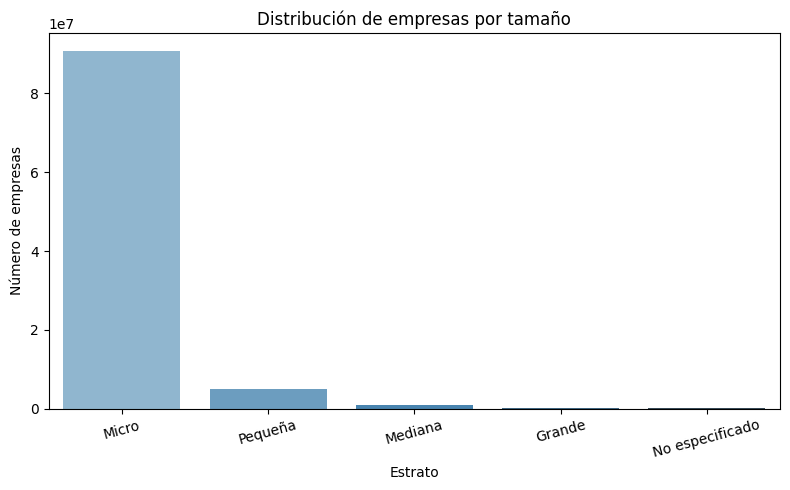

In [5]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_tamanio, x='estrato', y='total', palette='Blues_d')
plt.title('Distribución de empresas por tamaño')
plt.xlabel('Estrato')
plt.ylabel('Número de empresas')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('docs/fig1_tamanio.png', dpi=150)
plt.show()

In [6]:
df_sectores = pd.read_sql("""
    SELECT
        s.sector_nombre AS sector,
        COUNT(*) AS total
    FROM fact_empresas f
    JOIN dim_sector s ON f.sector_id = s.sector_id
    GROUP BY s.sector_nombre
    ORDER BY total DESC
    LIMIT 50
""", engine)

df_sectores

,sector,total
0,"Comercio Al Por Menor En Tiendas De Abarrotes,...",11179147
1,Salones Y Clínicas De Belleza Y Peluquerías,3864442
2,"Comercio Al Por Menor De Ropa, Excepto De Bebé...",2596597
3,Restaurantes Con Servicio De Preparación De An...,2391432
4,Restaurantes Con Servicio De Preparación De Ta...,2310901
5,Comercio Al Por Menor De Artículos De Papelería,2209465
6,Elaboración De Tortillas De Maíz Y Molienda De...,1919802
7,Comercio Al Por Menor De Frutas Y Verduras Fre...,1657778
8,Reparación Mecánica En General De Automóviles ...,1551376
9,Asociaciones Y Organizaciones Religiosas,1510018


C:\Users\axela\AppData\Local\Temp\ipykernel_22660\1345335117.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sectores, y='sector', x='total', palette='viridis')


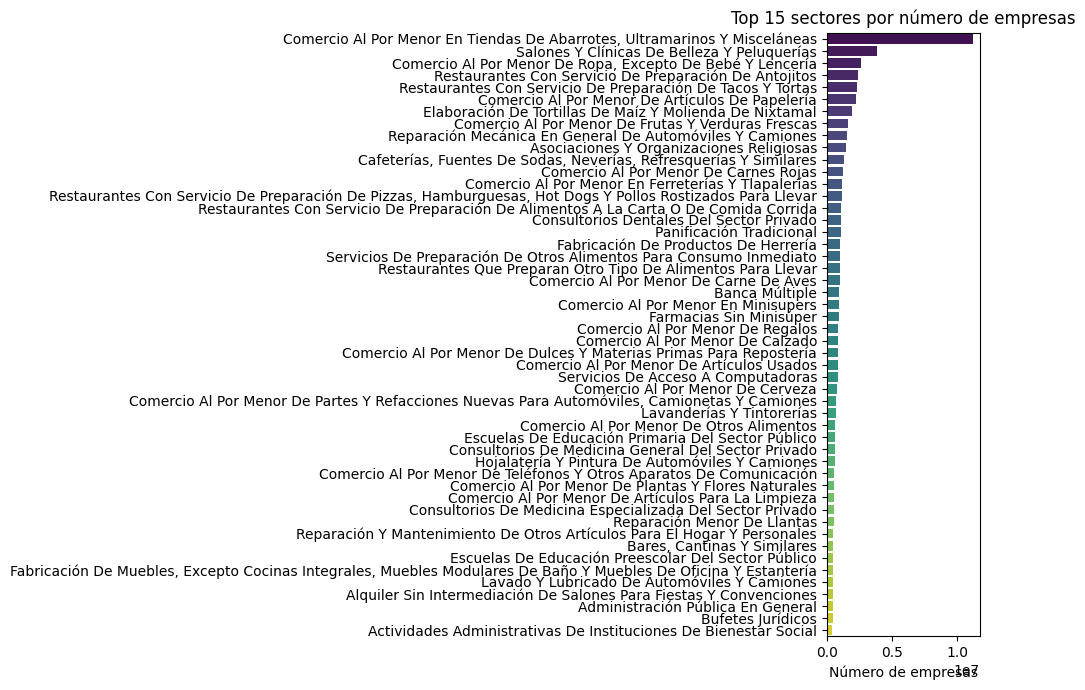

In [7]:
plt.figure(figsize=(10, 7))
sns.barplot(data=df_sectores, y='sector', x='total', palette='viridis')
plt.title('Top 15 sectores por número de empresas')
plt.xlabel('Número de empresas')
plt.ylabel('')
plt.tight_layout()
plt.savefig('docs/fig2_sectores.png', dpi=150)
plt.show()

In [8]:
df_estados = pd.read_sql("""
    SELECT
        g.entidad AS estado,
        COUNT(*) AS total
    FROM fact_empresas f
    JOIN dim_geografia g ON f.geo_id = g.geo_id
    GROUP BY g.entidad
    ORDER BY total DESC
    LIMIT 50
""", engine)

df_estados

,estado,total
0,MEXICO,12216170
1,CIUDAD DE MEXICO,8440156
2,JALISCO,6758770
3,PUEBLA,6026358
4,VERACRUZ DE IGNACIO DE LA LLAVE,5724095
5,GUANAJUATO,4846765
6,MICHOACAN DE OCAMPO,4506775
7,OAXACA,4259766
8,CHIAPAS,3784698
9,NUEVO LEON,3248316


C:\Users\axela\AppData\Local\Temp\ipykernel_22660\605275934.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_estados, y='estado', x='total', palette='rocket')


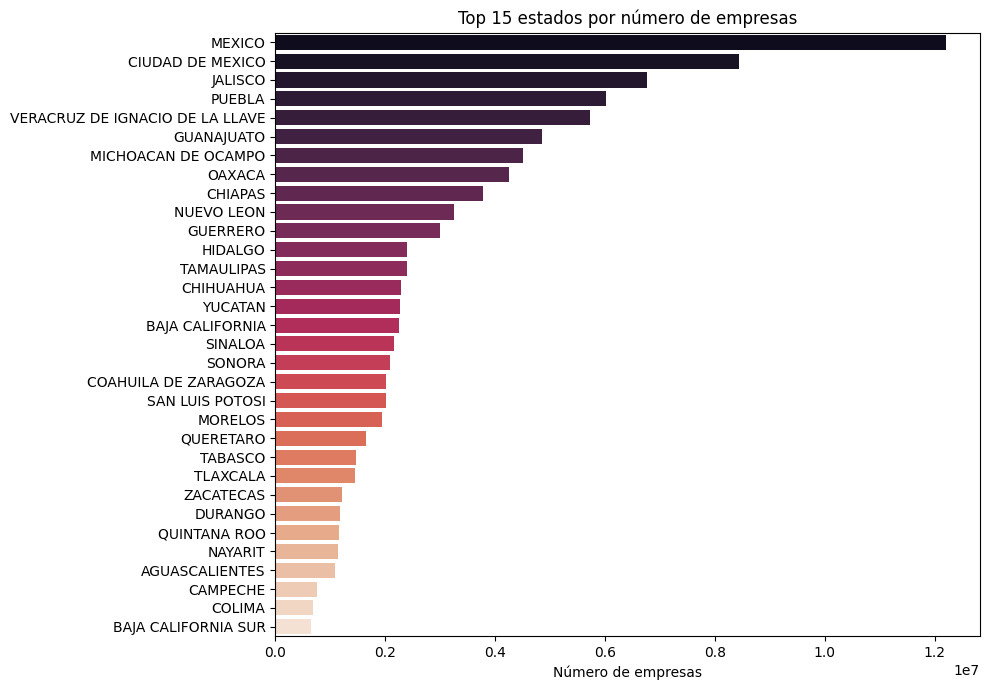

In [9]:
plt.figure(figsize=(10, 7))
sns.barplot(data=df_estados, y='estado', x='total', palette='rocket')
plt.title('Top 15 estados por número de empresas')
plt.xlabel('Número de empresas')
plt.ylabel('')
plt.tight_layout()
plt.savefig('docs/fig3_estados.png', dpi=150)
plt.show()

In [10]:
df_tiempo = pd.read_sql("""
    SELECT
        EXTRACT(YEAR FROM fecha) AS anio,
        COUNT(*) AS altas
    FROM fact_empresas
    WHERE fecha IS NOT NULL
      AND EXTRACT(YEAR FROM fecha) BETWEEN 1990 AND 2024
    GROUP BY anio
    ORDER BY anio
""", engine)

df_tiempo

,anio,altas
0,2010.0,27873850
1,2011.0,241880
2,2012.0,180599
3,2013.0,177127
4,2014.0,16991509
5,2016.0,728633
6,2017.0,252457
7,2018.0,517317
8,2019.0,22601510
9,2020.0,819763


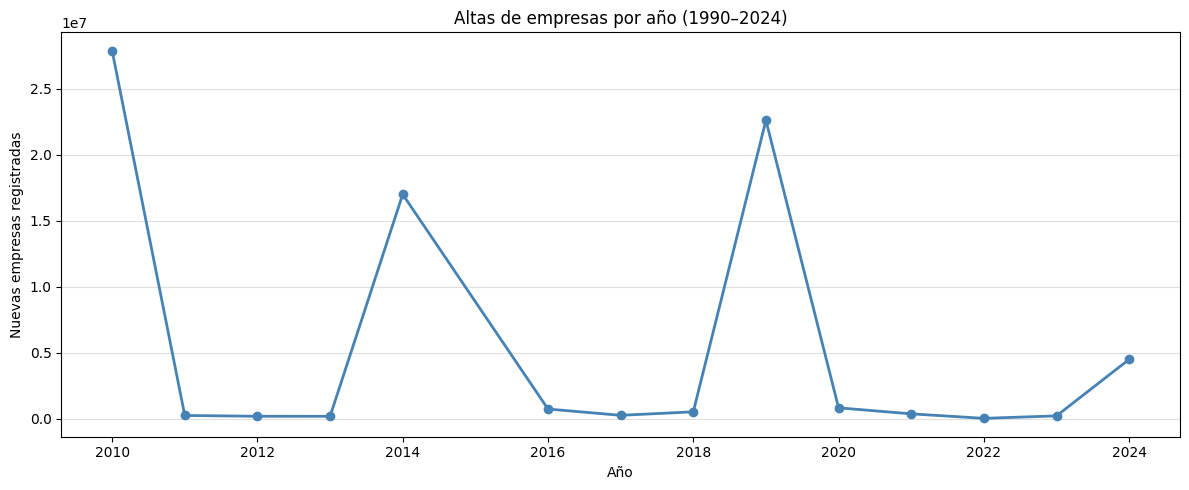

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df_tiempo['anio'], df_tiempo['altas'], marker='o', color='steelblue', linewidth=2)
plt.title('Altas de empresas por año (1990–2024)')
plt.xlabel('Año')
plt.ylabel('Nuevas empresas registradas')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('docs/fig4_temporal.png', dpi=150)
plt.show()

In [12]:
df_digital = pd.read_sql("""
    SELECT
        g.entidad AS estado,
        COUNT(*) AS total,
        ROUND(SUM(CASE WHEN f.tiene_web THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS pct_web,
        ROUND(SUM(CASE WHEN f.tiene_email THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS pct_email
    FROM fact_empresas f
    JOIN dim_geografia g ON f.geo_id = g.geo_id
    GROUP BY g.entidad
    ORDER BY pct_web DESC
    LIMIT 50
""", engine)

df_digital

,estado,total,pct_web,pct_email
0,NUEVO LEON,3248316,9.7,20.1
1,QUERETARO,1647559,8.9,19.3
2,QUINTANA ROO,1162455,8.9,16.7
3,CIUDAD DE MEXICO,8440156,7.5,15.2
4,BAJA CALIFORNIA,2242099,7.3,20.2
5,BAJA CALIFORNIA SUR,649875,7.2,20.3
6,SONORA,2096084,7.1,18.7
7,AGUASCALIENTES,1093910,6.2,19.1
8,SINALOA,2160190,5.7,13.5
9,COLIMA,683365,5.6,15.4


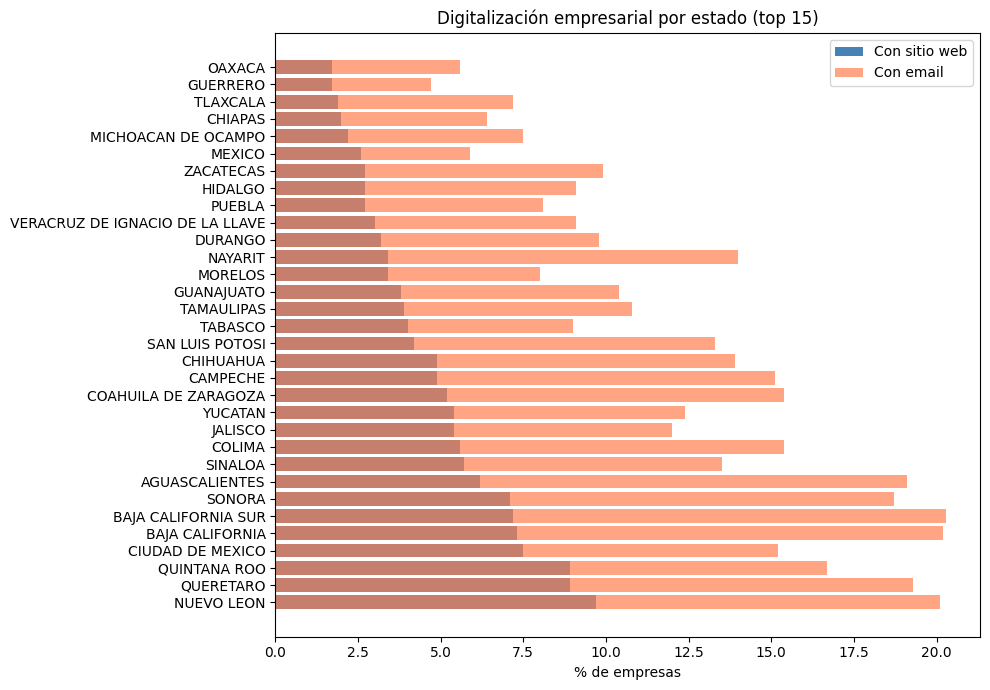

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
x = range(len(df_digital))
ax.barh(df_digital['estado'], df_digital['pct_web'], label='Con sitio web', color='steelblue')
ax.barh(df_digital['estado'], df_digital['pct_email'], label='Con email', color='coral', alpha=0.7)
ax.set_title('Digitalización empresarial por estado (top 15)')
ax.set_xlabel('% de empresas')
ax.legend()
plt.tight_layout()
plt.savefig('docs/fig5_digitalizacion.png', dpi=150)
plt.show()